# Ensure we can neglect ocean_tide gradient

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da

import matplotlib.pyplot as plt

import os
from glob import glob
from swot import browse_swot_250m, browse_swot_2km, add_grid_metrics, rotate_ggd
from cstes import swot_dir_2km, zarr_dir

In [2]:
files = sorted(glob(os.path.join(swot_dir_2km, '3_*')))

In [6]:
v = ['duacs_internal_tide_hret',
     'duacs_mean_dynamic_topography', 
     'duacs_mean_sea_surface_cnescls',
     'duacs_ssha_karin_2_filtered',
     'duacs_ssha_karin_2_calibrated',
     'cvl_ocean_tide_fes_2022',
     'duacs_editing_flag']

def preprocess(ds) :
    ds['time'] = (ds.time - np.timedelta64(946684800000000000, 'ns'))
    #ds['time_mean'] = ds['time'].mean().values
    ds['cycle_number'] = int(f.split("/")[-1].replace(".zarr","").split("_")[1])
    ds = ds.set_coords('cycle_number').expand_dims(dim='cycle_number')
    return ds

In [50]:
ds = xr.open_mfdataset(os.path.join(swot_dir_2km, '3_*'), preprocess = preprocess, data_vars = v)

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: Runt

KeyboardInterrupt: 

In [7]:
D =[]
for f in files :
    D.append(preprocess(xr.open_dataset(f)[v]))
    print(f)
    

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


/home/datawork-lops-oc/aponte/swot/cswot/swot/L3_calval_2.0.1/3_474.zarr
/home/datawork-lops-oc/aponte/swot/cswot/swot/L3_calval_2.0.1/3_475.zarr


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


/home/datawork-lops-oc/aponte/swot/cswot/swot/L3_calval_2.0.1/3_476.zarr
/home/datawork-lops-oc/aponte/swot/cswot/swot/L3_calval_2.0.1/3_478.zarr


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


...

/home/datawork-lops-oc/aponte/swot/cswot/swot/L3_calval_2.0.1/3_575.zarr
/home/datawork-lops-oc/aponte/swot/cswot/swot/L3_calval_2.0.1/3_576.zarr


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


/home/datawork-lops-oc/aponte/swot/cswot/swot/L3_calval_2.0.1/3_577.zarr
/home/datawork-lops-oc/aponte/swot/cswot/swot/L3_calval_2.0.1/3_578.zarr


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


ValueError: invalid literal for int() with base 10: 'concatenated'

In [8]:
ds = xr.concat(D, dim='cycle_number')

In [80]:
ds = ds.where(ds.duacs_editing_flag==0)
ds['adt'] = ds.duacs_mean_dynamic_topography + ds.duacs_ssha_karin_2_filtered

In [81]:
dsx = ds.differentiate('num_pixels')
dsy = ds.differentiate('num_lines')

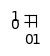

In [82]:
fig, ax_ = plt.subplots(1, 1,figsize=(0.1, 0.1), frameon=False)
def plot_histogram(darray, ax, bins=np.linspace(-1, 1, 60), **kwargs):
    a = darray.plot.hist(bins=bins, ax=ax_, density=True)
    h, bins = a[0], a[1]
    ax.plot(bins[:-1] + np.diff(bins) / 2, h, **kwargs)

In [70]:
v = ['duacs_mean_dynamic_topography',
     #'duacs_mean_sea_surface_cnescls',
     'duacs_ssha_karin_2_filtered',
     #'duacs_ssha_karin_2_calibrated',
     'cvl_ocean_tide_fes_2022',
    'duacs_internal_tide_hret',
     #'duacs_editing_flag'
    ]

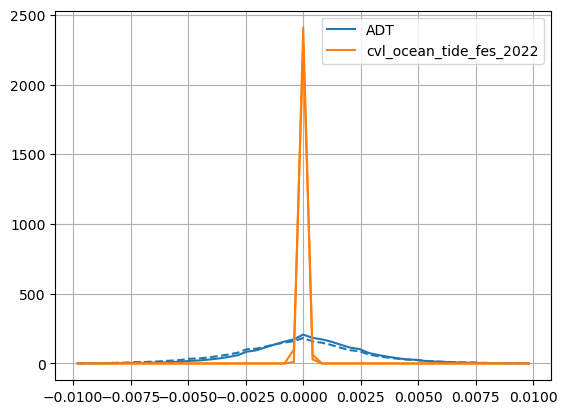

In [86]:
fig, ax = plt.subplots(1, 1, frameon=False)

plot_histogram(dsx['adt'], ax, bins=np.linspace(-1e-2, 1e-2, 50), c='tab:blue', label='ADT')
plot_histogram(dsy['adt'], ax, bins=np.linspace(-1e-2, 1e-2, 50), c='tab:blue', ls='--')
plot_histogram(dsx['cvl_ocean_tide_fes_2022'], ax, bins=np.linspace(-1e-2, 1e-2, 50),c='tab:orange', label='cvl_ocean_tide_fes_2022')
plot_histogram(dsy['cvl_ocean_tide_fes_2022'], ax, bins=np.linspace(-1e-2, 1e-2, 50),c='tab:orange',)

ax.legend()
ax.grid()

In [90]:
dsx.var()/dsx.adt.var()

<xarray.Dataset> Size: 64B
Dimensions:                         ()
Data variables:
    duacs_internal_tide_hret        float64 8B 0.0002862
    duacs_mean_dynamic_topography   float64 8B 0.08996
    duacs_mean_sea_surface_cnescls  float64 8B 99.92
    duacs_ssha_karin_2_filtered     float64 8B 0.9238
    duacs_ssha_karin_2_calibrated   float64 8B 2.364
    cvl_ocean_tide_fes_2022         float64 8B 0.002099
    duacs_editing_flag              float64 8B 0.0
    adt                             float64 8B 1.0

In [91]:
dsy.var()/dsy.adt.var()

<xarray.Dataset> Size: 64B
Dimensions:                         ()
Data variables:
    duacs_internal_tide_hret        float64 8B 0.0001903
    duacs_mean_dynamic_topography   float64 8B 0.2007
    duacs_mean_sea_surface_cnescls  float64 8B 269.0
    duacs_ssha_karin_2_filtered     float64 8B 0.8374
    duacs_ssha_karin_2_calibrated   float64 8B 1.957
    cvl_ocean_tide_fes_2022         float64 8B 0.000944
    duacs_editing_flag              float64 8B 0.0
    adt                             float64 8B 1.0

In [92]:
dsx.std()

<xarray.Dataset> Size: 64B
Dimensions:                         ()
Data variables:
    duacs_internal_tide_hret        float64 8B 4.563e-05
    duacs_mean_dynamic_topography   float64 8B 0.0008089
    duacs_mean_sea_surface_cnescls  float64 8B 0.02696
    duacs_ssha_karin_2_filtered     float64 8B 0.002592
    duacs_ssha_karin_2_calibrated   float64 8B 0.004147
    cvl_ocean_tide_fes_2022         float64 8B 0.0001236
    duacs_editing_flag              float64 8B 0.0
    adt                             float64 8B 0.002697

In [93]:
dsy.std()

<xarray.Dataset> Size: 64B
Dimensions:                         ()
Data variables:
    duacs_internal_tide_hret        float64 8B 4.158e-05
    duacs_mean_dynamic_topography   float64 8B 0.00135
    duacs_mean_sea_surface_cnescls  float64 8B 0.04944
    duacs_ssha_karin_2_filtered     float64 8B 0.002758
    duacs_ssha_karin_2_calibrated   float64 8B 0.004216
    cvl_ocean_tide_fes_2022         float64 8B 9.261e-05
    duacs_editing_flag              float64 8B 0.0
    adt                             float64 8B 0.003014